In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC

# from sklearn.linear_model import


In [3]:
df = pd.read_csv("/content/Students_Grading_Dataset.csv")
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [5]:
cnd1 = df["Attendance (%)"].isna()
cnd2 = df["Assignments_Avg"].isna()
cnd3 = df["Parent_Education_Level"].isna()

In [6]:
df[cnd1].head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
5,S1005,Liam,Brown,student5@university.com,Male,21,Engineering,NaN,78.85,43.53,...,67.29,62.08,B,8.5,Yes,Yes,PhD,High,1,5.0
32,S1032,Maria,Smith,student32@university.com,Female,21,CS,NaN,61.59,98.60,...,55.65,51.99,D,28.9,No,Yes,NaN,Medium,9,4.4
46,S1046,Liam,Smith,student46@university.com,Male,24,CS,NaN,69.91,44.14,...,96.58,82.90,C,13.5,No,Yes,Master's,Low,5,8.6
54,S1054,Omar,Smith,student54@university.com,Male,19,Business,NaN,52.45,85.21,...,92.48,82.55,B,5.3,No,Yes,High School,Medium,8,6.8
81,S1081,Maria,Johnson,student81@university.com,Female,23,CS,NaN,87.98,42.12,...,77.46,72.43,D,10.8,No,Yes,Master's,Low,1,5.4


In [7]:
df[cnd2].head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
20,S1020,Emma,Davis,student20@university.com,Male,18,CS,77.13,69.94,46.70,...,74.07,88.47,D,16.9,No,Yes,High School,Medium,2,8.1
55,S1055,Maria,Brown,student55@university.com,Female,19,Business,81.75,52.50,50.77,...,81.44,88.76,A,5.1,No,Yes,NaN,Medium,2,7.4
61,S1061,Omar,Davis,student61@university.com,Male,19,CS,82.34,94.72,93.70,...,57.93,88.60,B,22.0,No,Yes,NaN,Low,3,4.8
76,S1076,Maria,Williams,student76@university.com,Female,21,Engineering,70.77,70.22,66.31,...,56.51,58.85,A,26.7,No,Yes,NaN,High,1,4.7


In [8]:
df[cnd3].head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,NaN,Low,5,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19,Engineering,51.91,45.67,73.96,...,93.24,81.93,F,27.3,Yes,No,NaN,Medium,4,4.3
9,S1009,Sara,Smith,student9@university.com,Female,22,Engineering,64.01,87.96,98.47,...,78.60,84.99,A,9.6,No,Yes,NaN,Medium,10,6.4
13,S1013,John,Williams,student13@university.com,Male,18,Business,96.61,40.64,93.14,...,81.48,77.93,A,22.8,No,Yes,NaN,Medium,10,7.9


In [9]:
missing_columns = df.columns[df.isna().any()]

In [41]:
for col in missing_columns:
  if (df[col].dtype == "object"):
    mode_val = df[col].mode()[0]
    print(mode_val)
    df[col] = df[col].fillna(mode_val)
  else:
    mean_val = df[col].mean()
    print(mean_val)
    df[col] = df[col].fillna(mean_val)



75.431409455843
74.79867276377425
PhD


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [12]:
df[cnd1]

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
5,S1005,Liam,Brown,student5@university.com,Male,21,Engineering,75.431409,78.85,43.53,...,67.29,62.08,B,8.5,Yes,Yes,PhD,High,1,5.0
32,S1032,Maria,Smith,student32@university.com,Female,21,CS,75.431409,61.59,98.60,...,55.65,51.99,D,28.9,No,Yes,PhD,Medium,9,4.4
46,S1046,Liam,Smith,student46@university.com,Male,24,CS,75.431409,69.91,44.14,...,96.58,82.90,C,13.5,No,Yes,Master's,Low,5,8.6
54,S1054,Omar,Smith,student54@university.com,Male,19,Business,75.431409,52.45,85.21,...,92.48,82.55,B,5.3,No,Yes,High School,Medium,8,6.8
81,S1081,Maria,Johnson,student81@university.com,Female,23,CS,75.431409,87.98,42.12,...,77.46,72.43,D,10.8,No,Yes,Master's,Low,1,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4951,S5951,Emma,Smith,student4951@university.com,Female,22,CS,75.431409,86.92,50.88,...,95.62,52.59,F,14.1,No,Yes,Master's,Low,8,7.5
4988,S5988,John,Smith,student4988@university.com,Female,19,Engineering,75.431409,59.39,80.37,...,96.74,63.42,A,13.5,No,Yes,PhD,Low,5,6.4
4992,S5992,Sara,Johnson,student4992@university.com,Male,18,CS,75.431409,61.44,64.59,...,80.08,62.51,A,23.3,Yes,No,High School,Medium,1,6.2
4994,S5994,John,Johnson,student4994@university.com,Female,19,Mathematics,75.431409,69.92,55.48,...,64.36,55.88,F,25.5,No,Yes,High School,Low,2,4.1


In [13]:
df[cnd2].head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,PhD,Medium,4,9.0
20,S1020,Emma,Davis,student20@university.com,Male,18,CS,77.13,69.94,46.70,...,74.07,88.47,D,16.9,No,Yes,High School,Medium,2,8.1
55,S1055,Maria,Brown,student55@university.com,Female,19,Business,81.75,52.50,50.77,...,81.44,88.76,A,5.1,No,Yes,PhD,Medium,2,7.4
61,S1061,Omar,Davis,student61@university.com,Male,19,CS,82.34,94.72,93.70,...,57.93,88.60,B,22.0,No,Yes,PhD,Low,3,4.8
76,S1076,Maria,Williams,student76@university.com,Female,21,Engineering,70.77,70.22,66.31,...,56.51,58.85,A,26.7,No,Yes,PhD,High,1,4.7


In [14]:
df[cnd3].head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,PhD,Medium,4,9.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,PhD,Low,5,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19,Engineering,51.91,45.67,73.96,...,93.24,81.93,F,27.3,Yes,No,PhD,Medium,4,4.3
9,S1009,Sara,Smith,student9@university.com,Female,22,Engineering,64.01,87.96,98.47,...,78.60,84.99,A,9.6,No,Yes,PhD,Medium,10,6.4
13,S1013,John,Williams,student13@university.com,Male,18,Business,96.61,40.64,93.14,...,81.48,77.93,A,22.8,No,Yes,PhD,Medium,10,7.9


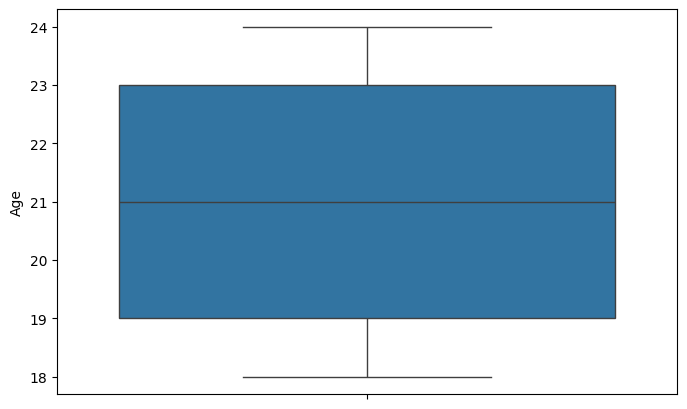

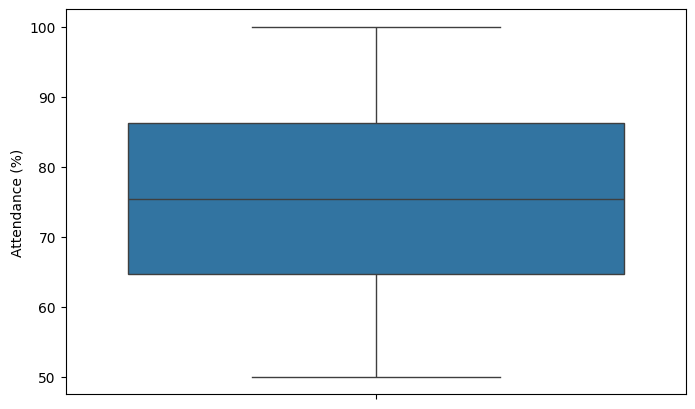

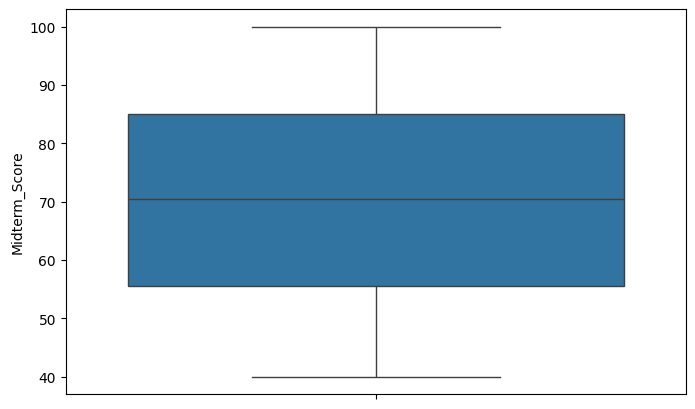

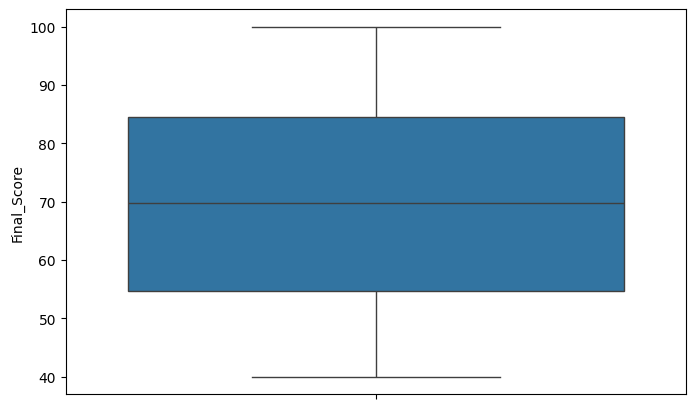

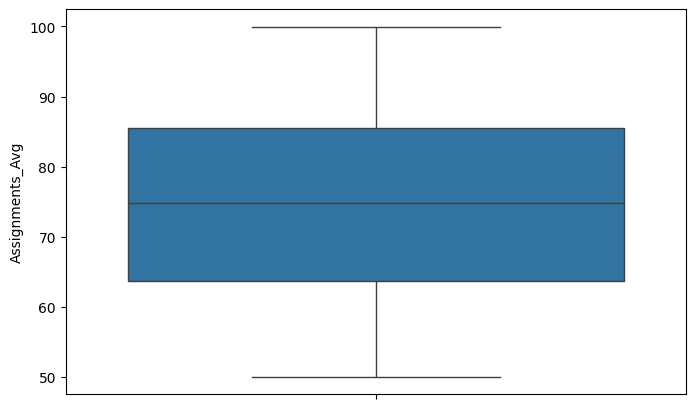

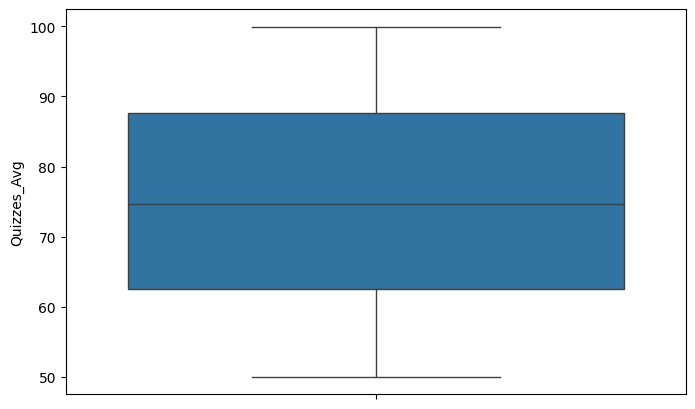

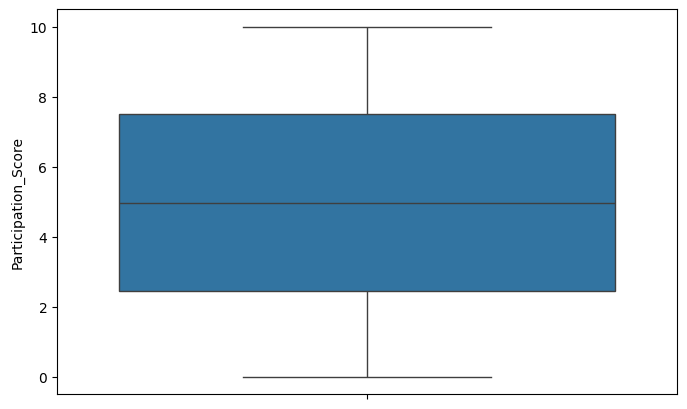

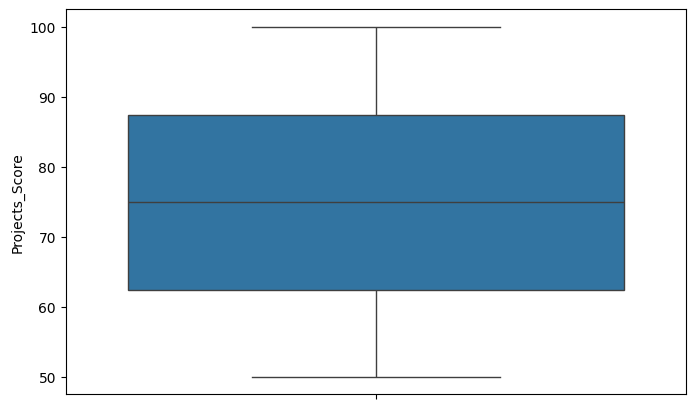

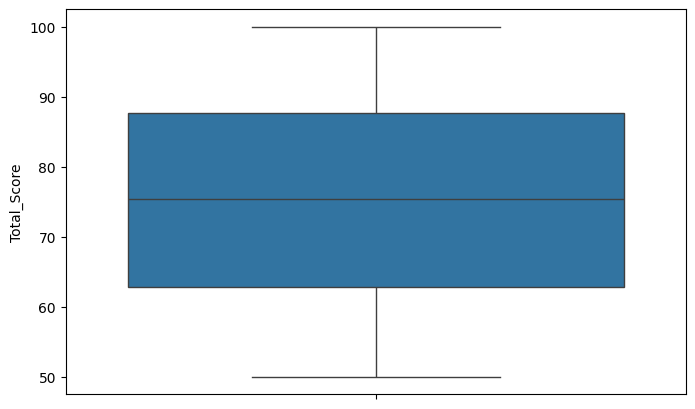

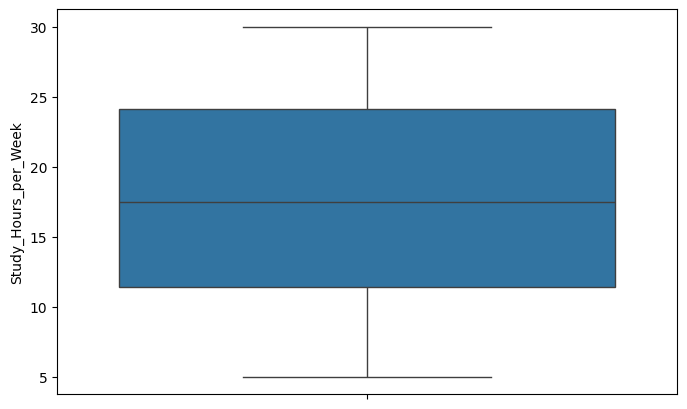

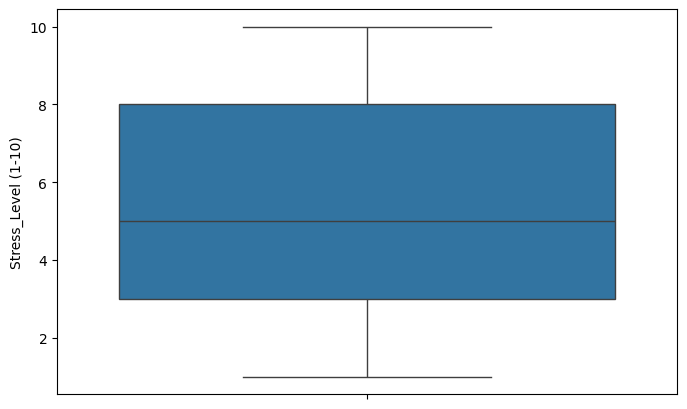

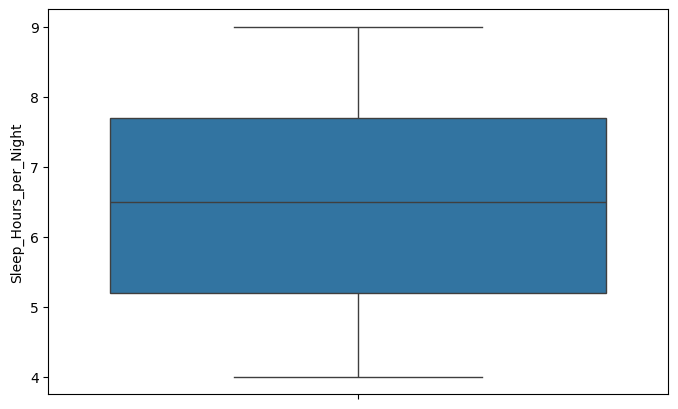

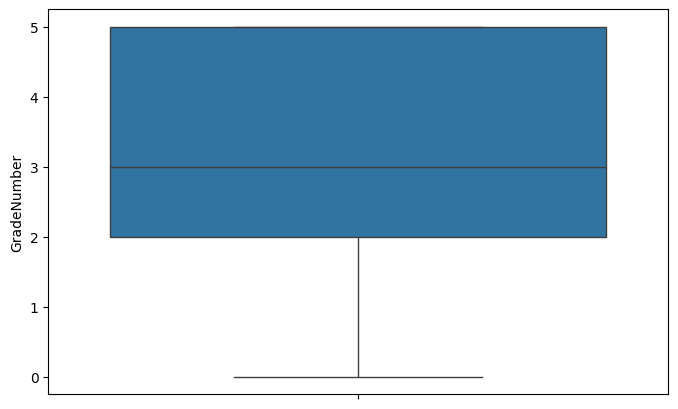

In [44]:
for col in df.columns:
  if (df[col].dtype != "object"):
    plt.figure(figsize=(8,5))
    sns.boxplot(df[col])
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    UB = Q3 + 1.5*IQR
    LB = Q1 - 1.5*IQR
    df = df[(df[col] >= LB) & (df[col] <= UB)]

Text(0.5, 1.0, 'Heat Map')

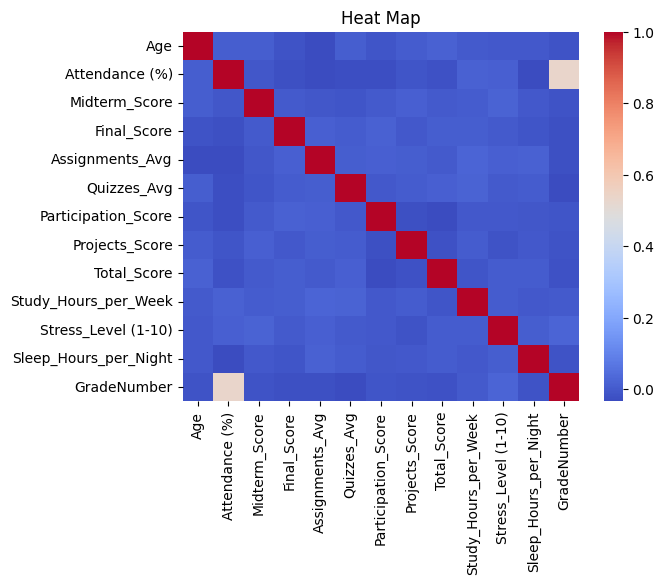

In [45]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Heat Map")

                       GradeNumber
Age                      -0.015787
Attendance (%)            0.534007
Midterm_Score            -0.018139
Final_Score              -0.025676
Assignments_Avg          -0.022897
Quizzes_Avg              -0.030941
Participation_Score      -0.013111
Projects_Score           -0.016486
Total_Score              -0.019763
Study_Hours_per_Week     -0.001711
Stress_Level (1-10)       0.023353
Sleep_Hours_per_Night    -0.017794
GradeNumber               1.000000


<Axes: >

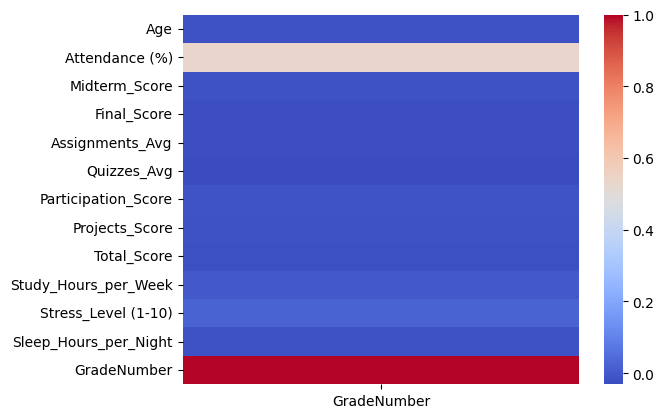

In [16]:
def func(x):
  if(x == "A"):
    return 5
  elif(x == "B"):
    return 4
  elif(x == "C"):
    return 3
  elif(x == "D"):
    return 2
  else:
    return 0

new_df = df
new_df["GradeNumber"] = new_df["Grade"].apply(lambda x : func(x))
corr = new_df.corr(numeric_only=True)[["GradeNumber"]]
print(corr)
sns.heatmap(corr, cmap="coolwarm")

In [17]:
df["Grade"].value_counts()

,count
Grade,
A,1495
B,978
D,889
F,844
C,794


In [18]:
Pred = df.columns[6:21]
Pred = Pred.drop("Grade","GradeNumber")
print(Pred)
print(df[Pred].shape)

Target = "Grade"

Index(['Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level'],
      dtype='object')
(5000, 14)


In [19]:
cols = ["Department","Extracurricular_Activities","Internet_Access_at_Home","Parent_Education_Level","Family_Income_Level"]
encoded_data = pd.get_dummies(df[Pred],columns = cols)
print(encoded_data.columns)

Index(['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg',
       'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score',
       'Study_Hours_per_Week', 'Department_Business', 'Department_CS',
       'Department_Engineering', 'Department_Mathematics',
       'Extracurricular_Activities_No', 'Extracurricular_Activities_Yes',
       'Internet_Access_at_Home_No', 'Internet_Access_at_Home_Yes',
       'Parent_Education_Level_Bachelor's',
       'Parent_Education_Level_High School', 'Parent_Education_Level_Master's',
       'Parent_Education_Level_PhD', 'Family_Income_Level_High',
       'Family_Income_Level_Low', 'Family_Income_Level_Medium'],
      dtype='object')


In [20]:
encoded_data.shape

(5000, 24)

In [21]:
scalar = StandardScaler()
cols = ['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg',
       'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score',
       'Study_Hours_per_Week']
encoded_data_normalised = encoded_data
encoded_data_normalised[cols] = scalar.fit_transform(encoded_data_normalised[cols])
encoded_data_normalised.head()

,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Department_Business,...,Extracurricular_Activities_Yes,Internet_Access_at_Home_No,Internet_Access_at_Home_Yes,Parent_Education_Level_Bachelor's,Parent_Education_Level_High School,Parent_Education_Level_Master's,Parent_Education_Level_PhD,Family_Income_Level_High,Family_Income_Level_Low,Family_Income_Level_Medium
0,-1.700434,-0.888758,-0.685779,6.904670e-01,-0.058659,-0.342587,0.761001,-1.321791,-1.575071,False,...,False,False,True,False,True,False,False,False,False,True
1,1.604703,1.563093,-1.383115,1.041480e-15,1.332793,1.155762,-1.336493,-1.700302,0.184346,False,...,False,False,True,False,False,False,True,False,False,True
2,-1.340381,-0.190387,1.394627,-5.202451e-01,0.743943,0.024214,-0.078690,-0.334882,0.418018,True,...,False,False,True,False,False,True,False,False,True,False
3,1.448925,-1.309407,0.637535,-6.404369e-01,1.282458,0.539813,1.192288,-0.937028,0.981582,False,...,True,False,True,False,True,False,False,True,False,False
4,-1.561556,-1.379128,0.536590,1.616090e+00,0.606038,0.342570,-0.451038,-0.624496,-0.310490,False,...,True,False,True,False,True,False,False,True,False,False


In [22]:
X = encoded_data_normalised
Y = df["Grade"]

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=100)

In [24]:
X_train.shape

(4000, 24)

In [25]:
Y_test.shape

(1000,)

In [32]:
model = SVC()
model.fit(X_train, Y_train)

SVC()

In [38]:
Y_test_pred = model.predict(X_test)

print("Test Accuracy: ", accuracy_score(Y_test_pred, Y_test))
print("Precision: ", precision_score(Y_test_pred, Y_test, average='weighted'))
print("Recall: ", recall_score(Y_test_pred, Y_test, average='weighted'))
print("F1 Score: ", f1_score(Y_test_pred, Y_test, average='weighted'))
print("Confusion Matrix: \n", confusion_matrix(Y_test_pred, Y_test))
print("Classification Report: \n", classification_report(Y_test_pred, Y_test))

Test Accuracy:  0.374
Precision:  0.5119747099685541
Recall:  0.374
F1 Score:  0.41974257962150385
Confusion Matrix: 
 [[227 135  42  51  43]
 [ 10  15   8   7  16]
 [ 14  17  20  19  25]
 [ 31  19  41  78  54]
 [ 19  18  25  32  34]]
Classification Report: 
               precision    recall  f1-score   support

           A       0.75      0.46      0.57       498
           B       0.07      0.27      0.12        56
           C       0.15      0.21      0.17        95
           D       0.42      0.35      0.38       223
           F       0.20      0.27      0.23       128

    accuracy                           0.37      1000
   macro avg       0.32      0.31      0.29      1000
weighted avg       0.51      0.37      0.42      1000



In [40]:
model = SVC()
grid = GridSearchCV(
    model,
    param_grid={},
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train,Y_train)
model_df = pd.DataFrame(grid.cv_results_)

print("Best Params: ", grid.best_params_)
print("Best Cross Validation: ", grid.best_score_)


Best Params:  {}
Best Cross Validation:  0.35974999999999996
Best Estimator Cross Validation:  0.374


In [29]:
model = SVC()
param_grid={
    'C':[0.1,5,20],
    'kernel':['linear', 'rbf'],
    'gamma':['auto','scale']
}
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train,Y_train)
model_df = pd.DataFrame(grid.cv_results_)

print("Best Params: ", grid.best_params_)
print("Best Cross Validation: ", grid.best_score_)

Best Params:  {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}
Best Cross Validation:  0.373
